In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape, deliveries.shape)
print(deliveries.head())
print(deliveries.columns.tolist())

(1095, 20) (260920, 17)
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed di

In [3]:
# Total runs per batter per match
batter_match = deliveries.groupby(
    ['match_id', 'batter']
)['batsman_runs'].sum().reset_index()
batter_match.columns = ['match_id', 'batter', 'runs_scored']

# Merge with match info (venue, teams, season)
batter_match = batter_match.merge(
    matches[['id', 'season', 'venue', 'team1', 'team2']],
    left_on='match_id', right_on='id'
)

# Recent form — average runs in last 5 matches
batter_match = batter_match.sort_values(['batter', 'match_id'])
batter_match['last5_avg'] = (
    batter_match.groupby('batter')['runs_scored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Career average up to that match (no data leakage)
batter_match['career_avg'] = (
    batter_match.groupby('batter')['runs_scored']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Balls faced per match
balls = deliveries.groupby(
    ['match_id', 'batter']
).size().reset_index(name='balls_faced')
batter_match = batter_match.merge(balls, on=['match_id', 'batter'])

print(batter_match.head())

   match_id          batter  runs_scored      id season  \
0    548346  A Ashish Reddy           10  548346   2012   
1    548352  A Ashish Reddy            3  548352   2012   
2    548359  A Ashish Reddy            8  548359   2012   
3    548373  A Ashish Reddy           10  548373   2012   
4    548376  A Ashish Reddy            4  548376   2012   

                                       venue                team1  \
0                           Wankhede Stadium       Mumbai Indians   
1            MA Chidambaram Stadium, Chepauk  Chennai Super Kings   
2  Rajiv Gandhi International Stadium, Uppal      Deccan Chargers   
3  Rajiv Gandhi International Stadium, Uppal      Deccan Chargers   
4  Rajiv Gandhi International Stadium, Uppal      Deccan Chargers   

                         team2  last5_avg  career_avg  balls_faced  
0              Deccan Chargers        NaN         NaN           10  
1              Deccan Chargers      10.00       10.00            3  
2              Kings XI

In [5]:
from sklearn.preprocessing import LabelEncoder

df = batter_match.dropna()

# Encode categorical columns
le = LabelEncoder()
df['venue_enc'] = le.fit_transform(df['venue'])
df['batter_enc'] = le.fit_transform(df['batter'])
df['season'] = df['season'].astype(str).str[:4].astype(int)

features = [
    'batter_enc',
    'venue_enc',
    'season',
    'last5_avg',
    'career_avg',
    'balls_faced'
]
target = 'runs_scored'

X = df[features]
y = df[target]

# Train/test split — use last season as test
train = df[df['season'] < 2019]
test  = df[df['season'] >= 2019]

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

In [6]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

# Compare
for name, preds in [("Random Forest", rf_preds), ("XGBoost", xgb_preds)]:
    print(f"{name} → MAE: {mean_absolute_error(y_test, preds):.2f} | R²: {r2_score(y_test, preds):.3f}")

Random Forest → MAE: 5.75 | R²: 0.859
XGBoost → MAE: 5.65 | R²: 0.861


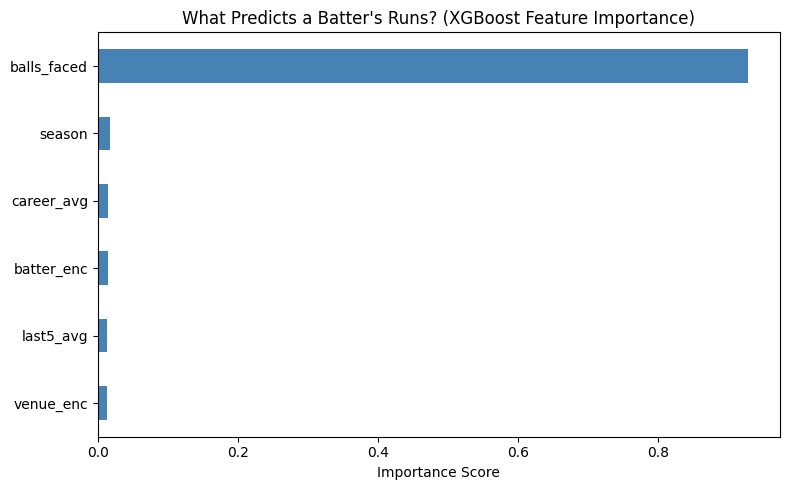

In [7]:
importances = pd.Series(xgb.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8,5))
plt.title('What Predicts a Batter\'s Runs? (XGBoost Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
# Example: Predict runs at a specific venue
player = 'F du Plessis'
player_data = df[df['batter'] == player].tail(1)

sample = pd.DataFrame([{
    'batter_enc': player_data['batter_enc'].values[0],
    'venue_enc': player_data['venue_enc'].values[0],
    'season': 2020,
    'last5_avg': player_data['last5_avg'].values[0],
    'career_avg': player_data['career_avg'].values[0],
    'balls_faced': 25  
}])

predicted_runs = xgb.predict(sample)[0]
print(f"Predicted runs for {player}: {predicted_runs:.1f}")

Predicted runs for F du Plessis: 34.0
